In [52]:
import urllib.request
import re

# Dataset nama orang Indonesia (Gist raw txt)
url = "https://gist.githubusercontent.com/maulvi/e443e22b82a1dc24e14344b47f0a80ea/raw/nama.txt"
urllib.request.urlretrieve(url, "nama_indonesia.txt")

# Baca dan bersihkan
raw_words = open("nama_indonesia.txt", "r").read().splitlines()

# Preprocessing: ambil yang alfabet saja (a-z) dan ubah jadi lowercase
words = [w.strip().lower() for w in raw_words if re.match(r'^[a-zA-Z]+$', w.strip())]
words = sorted(list(set(words)))  # hapus duplikat

print(f"Total nama unik: {len(words)}")
print(words[:15])
# Output biasanya seperti: ['aan', 'abdul', 'abdullah', 'abidin', 'achmad', 'adam', 'ade', 'adhi', 'adhitya', ...]

Total nama unik: 1005
['aan', 'abdul', 'abdullah', 'abidin', 'abie', 'achmad', 'adam', 'ade', 'adhi', 'adhitya', 'adi', 'adinda', 'adipati', 'adit', 'aditia']


In [61]:
import torch
import torch.nn.functional as F

# Read words
words = open('../02-makemore-part-1/names.txt', 'r').read().splitlines()

# Build vocabulary mapping (same 27 characters)
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

# 1. Update the block size
BLOCK_SIZE = 7

X, Y = [], []
for w in words:
    context = [0] * BLOCK_SIZE
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [62]:
g = torch.Generator().manual_seed(42)

# Hyperparameters
EMBEDDING_DIM = 10   # Each of the 27 chars gets a 10-dimensional vector
HIDDEN_DIM = 200     # Number of neurons in the hidden layer

# Parameters
C  = torch.randn((27, EMBEDDING_DIM), generator=g)          # Lookup table
W1 = torch.randn((BLOCK_SIZE * EMBEDDING_DIM, HIDDEN_DIM), generator=g) * 0.2
b1 = torch.randn(HIDDEN_DIM, generator=g) * 0.01
W2 = torch.randn((HIDDEN_DIM, 27), generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(f"Total trainable parameters: {sum(p.nelement() for p in parameters)}")

Total trainable parameters: 19897


In [63]:
# Training loop (run for 20,000 steps)
for step in range(20000):
    # 1. Minibatch construct (size 64)
    ix = torch.randint(0, X.shape[0], (64,), generator=g)
    Xb, Yb = X[ix], Y[ix]
    
    # 2. Forward pass
    # Retrieve embeddings for the 3 context chars and flatten them
    emb = C[Xb].view(Xb.shape[0], -1)  # shape: (64, 30)
    
    # Hidden layer with Tanh non-linearity
    h = torch.tanh(emb @ W1 + b1)      # shape: (64, 200)
    
    # Output layer (logits)
    logits = h @ W2 + b2               # shape: (64, 27)
    
    # Cross-entropy loss (handles softmax + NLL under the hood numerically stably)
    loss = F.cross_entropy(logits, Yb)
    
    # 3. Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # 4. Optimizer step (learning rate decay)
    lr = 0.1 if step < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if step % 2000 == 0:
        print(f"Step {step:5d} | Loss: {loss.item():.4f}")

Step     0 | Loss: 3.2935
Step  2000 | Loss: 2.5787
Step  4000 | Loss: 2.2986
Step  6000 | Loss: 2.3072
Step  8000 | Loss: 2.1510
Step 10000 | Loss: 2.3958
Step 12000 | Loss: 2.1461
Step 14000 | Loss: 1.9776
Step 16000 | Loss: 2.1905
Step 18000 | Loss: 2.2932


In [91]:
# Generate 10 names
for _ in range(20):
    out = []
    context = [0] * BLOCK_SIZE # Start with '...'
    
    while True:
        # Forward pass for current context
        emb = C[torch.tensor([context])].view(1, -1)
        h = torch.tanh(emb @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        # Sample next char from distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        if ix == 0: # Hit the '.' token -> stop
            break
            
        out.append(itos[ix])
        context = context[1:] + [ix] # Shift context
        
    print(''.join(out))

merelun
tocolina
leivin
aydanna
avron
jakona
ariha
tulene
peythe
mariyah
jaas
kaedra
susti
simen
kaidy
kaedule
saikora
marie
donron
kamel


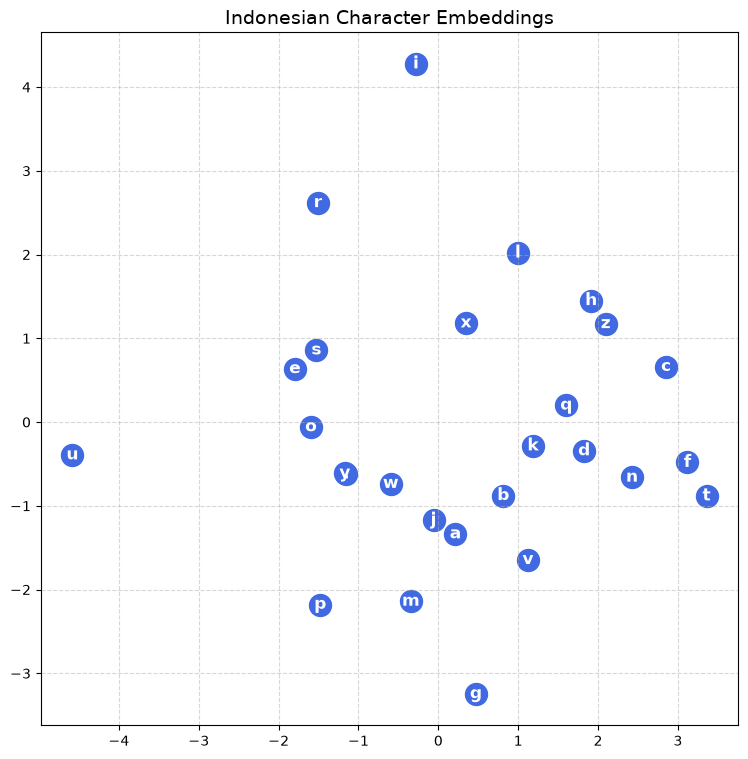

In [36]:
import matplotlib.pyplot as plt

# If your EMBEDDING_DIM is already 2:
if C.shape[1] == 2:
    plt.figure(figsize=(8, 8))
    plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
    for i in range(C.shape[0]):
        plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
    plt.grid('minor')
    plt.show()
else:
    # If EMBEDDING_DIM > 2, we can project to 2D using SVD or PCA
    U, S, V = torch.pca_lowrank(C, q=2)
    C_2d = torch.matmul(C, V[:, :2])
    
    plt.figure(figsize=(9, 9))
    plt.scatter(C_2d[:, 0].detach(), C_2d[:, 1].detach(), s=250, color='royalblue')
    for i in range(C.shape[0]):
        plt.text(C_2d[i, 0].item(), C_2d[i, 1].item(), itos[i], ha="center", va="center", color="white", weight='bold', fontsize=12)
    plt.title("Indonesian Character Embeddings", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()